# 03 - Model Training

In [1]:
# Cell 1 — Import
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.neural_network  import MLPClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics         import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

# Load dữ liệu đã xử lý
X_train = np.load('../models/X_train.npy')
X_test  = np.load('../models/X_test.npy')
y_train = np.load('../models/y_train.npy')
y_test  = np.load('../models/y_test.npy')

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (614, 8) | Test: (154, 8)


In [2]:
# Cell 2 — Hàm đánh giá model
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1-score : {f1_score(y_test, y_pred):.4f}")
    print(f"  AUC-ROC  : {roc_auc_score(y_test, y_prob):.4f}")
    return {
        "name":      name,
        "model":     model,
        "accuracy":  accuracy_score(y_test, y_pred),
        "f1":        f1_score(y_test, y_pred),
        "auc":       roc_auc_score(y_test, y_prob)
    }

In [3]:
# Cell 3 — Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
result_lr = evaluate('Logistic Regression', lr, X_test, y_test)


  Logistic Regression
  Accuracy : 0.7078
  Precision: 0.6000
  Recall   : 0.5000
  F1-score : 0.5455
  AUC-ROC  : 0.8130


In [4]:
# Cell 4 — Train Random Forest (có GridSearch tìm tham số tốt nhất)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)
rf = rf_grid.best_estimator_
print('Best params RF:', rf_grid.best_params_)
result_rf = evaluate('Random Forest', rf, X_test, y_test)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params RF: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

  Random Forest
  Accuracy : 0.7338
  Precision: 0.6444
  Recall   : 0.5370
  F1-score : 0.5859
  AUC-ROC  : 0.8043


In [5]:
# Cell 5 — Train SVM
from sklearn.svm import SVC
param_grid_svm = {
    'C':      [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale', 'auto']
}
svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
svm_grid.fit(X_train, y_train)
svm = svm_grid.best_estimator_
print('Best params SVM:', svm_grid.best_params_)
result_svm = evaluate('SVM', svm, X_test, y_test)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

  SVM
  Accuracy : 0.7403
  Precision: 0.6522
  Recall   : 0.5556
  F1-score : 0.6000
  AUC-ROC  : 0.7964


In [6]:
# Cell 6 — Train Neural Network (MLP)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
mlp.fit(X_train, y_train)
result_mlp = evaluate('Neural Network (MLP)', mlp, X_test, y_test)


  Neural Network (MLP)
  Accuracy : 0.7468
  Precision: 0.6667
  Recall   : 0.5556
  F1-score : 0.6061
  AUC-ROC  : 0.8185


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


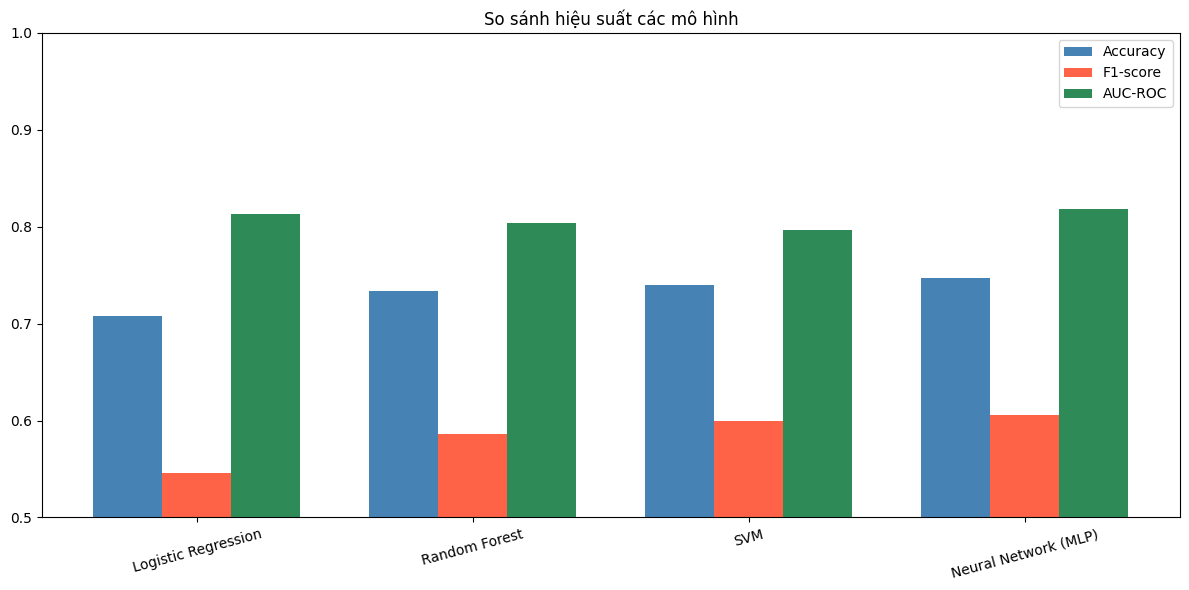

In [7]:
# Cell 7 — So sánh tất cả mô hình bằng biểu đồ
results = [result_lr, result_rf, result_svm, result_mlp]
names   = [r['name']     for r in results]
f1s     = [r['f1']       for r in results]
aucs    = [r['auc']      for r in results]
accs    = [r['accuracy'] for r in results]

x = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, accs, width, label='Accuracy', color='steelblue')
ax.bar(x,         f1s,  width, label='F1-score',  color='tomato')
ax.bar(x + width, aucs, width, label='AUC-ROC',   color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylim(0.5, 1.0)
ax.set_title('So sánh hiệu suất các mô hình')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Cell 8 — Chọn model tốt nhất theo F1 + AUC
best = max(results, key=lambda r: r["f1"] + r["auc"])
print(f"\n🏆 Model tốt nhất: {best['name']}")
print(f"   F1-score : {best['f1']:.4f}")
print(f"   AUC-ROC  : {best['auc']:.4f}")


🏆 Model tốt nhất: Neural Network (MLP)
   F1-score : 0.6061
   AUC-ROC  : 0.8185


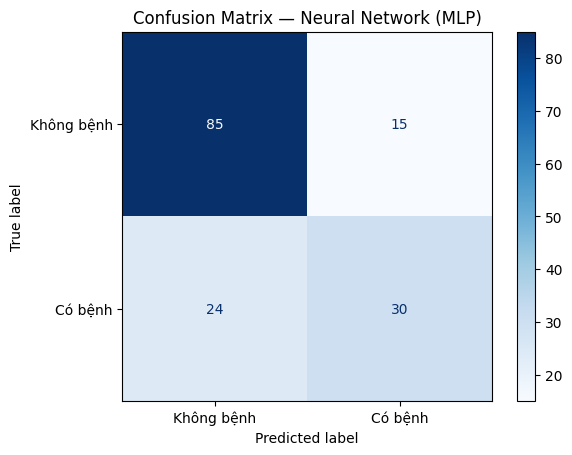

              precision    recall  f1-score   support

  Không bệnh       0.78      0.85      0.81       100
     Có bệnh       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



In [12]:
# Cell 9 — Confusion Matrix của model tốt nhất
y_pred = best["model"].predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Không bệnh", "Có bệnh"]); disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best['name']}")
plt.show()
print(classification_report(
    y_test, y_pred,
    target_names=["Không bệnh", "Có bệnh"]
))

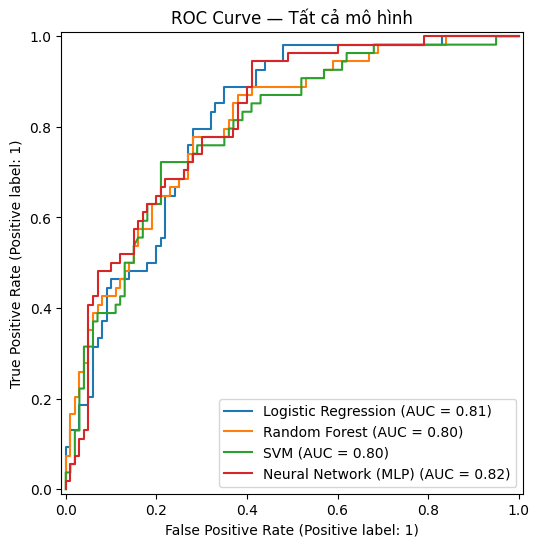

In [13]:
# Cell 10 — ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
for r in results:
    RocCurveDisplay.from_estimator(
        r['model'], X_test, y_test,
        name=r['name'], ax=ax
    )
ax.set_title('ROC Curve — Tất cả mô hình')
plt.show()

In [ ]:
# Cell 11 — ⭐ Lưu model tốt nhất
import joblib

joblib.dump(best["model"], "../models/best_model.pkl")

# Lưu thêm metadata để biết model nào được chọn
import json
metadata = {
    "model_name":    best["name"],
    "model_version": "v1.0",
    "f1_score":      round(best["f1"],  4),
    "auc_roc":       round(best["auc"], 4),
    "accuracy":      round(best["accuracy"], 4),
    "features": [
        "Pregnancies", "Glucose", "BloodPressure",
        "SkinThickness", "Insulin", "BMI",
        "DiabetesPedigreeFunction", "Age"
    ]
}
with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Đã lưu best_model.pkl  → {best['name']}")
print("✅ Đã lưu model_metadata.json")
print("✅ scaler.pkl đã có từ notebook 02")
print("\nThư mục models/ hiện có:")
import os
print("\n".join([f"  📄 {file_name}" for file_name in os.listdir("../models")]))

✅ Đã lưu best_model.pkl  → Neural Network (MLP)
✅ Đã lưu model_metadata.json
✅ scaler.pkl đã có từ notebook 02

Thư mục models/ hiện có:
  📄 best_model.pkl
  📄 model_metadata.json
  📄 scaler.pkl
  📄 X_test.npy
  📄 X_train.npy
  📄 y_test.npy
  📄 y_train.npy


: 